Human:
98.2388650900729
Damping: 0.013939031119531087
Frequency: 63.08418983112059


This browser does not support the video tag.


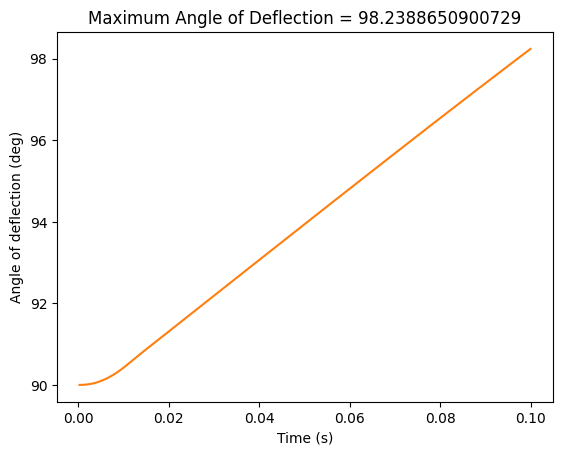

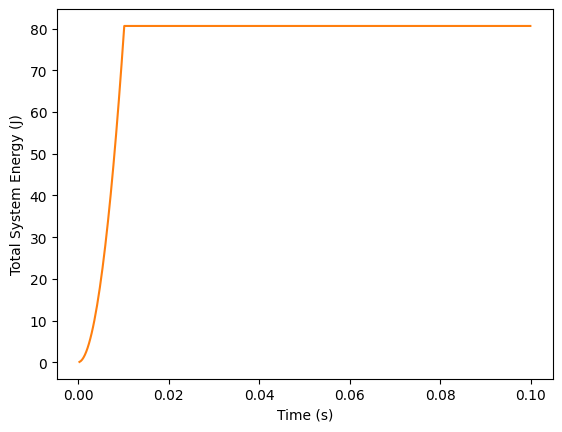

B value: 0.37188242583227954
B value: -0.3837441715078189


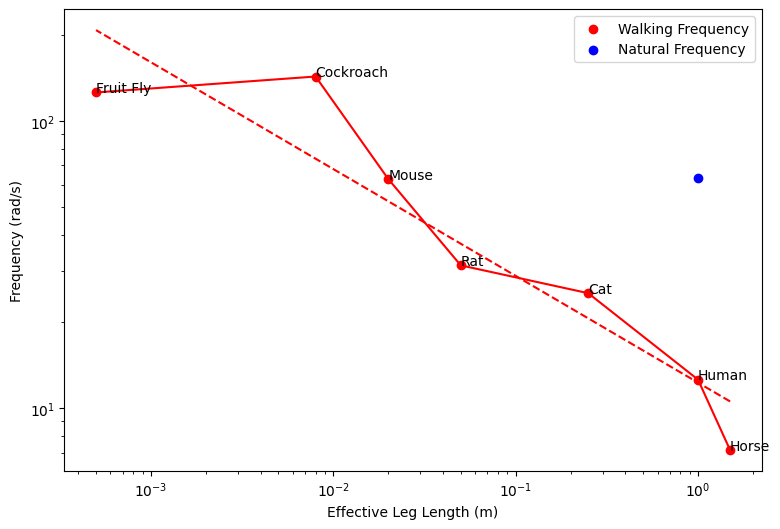

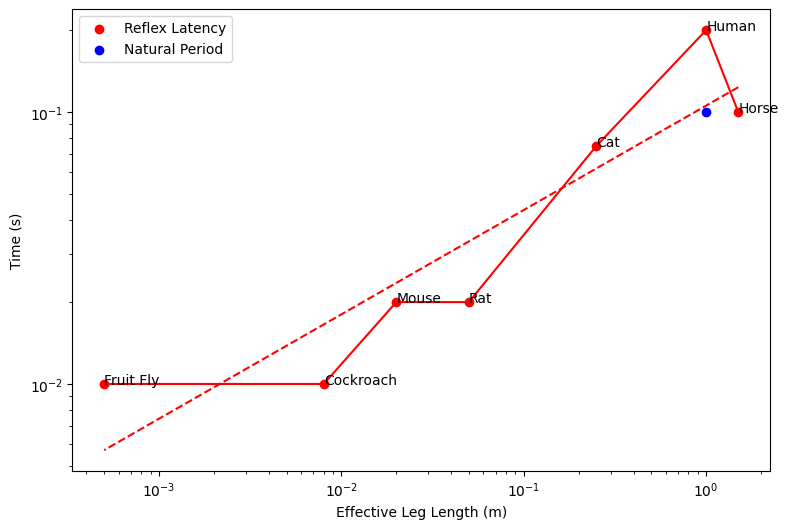

In [ ]:
import mujoco
import mediapy as media
import time
import itertools

# import datashader as ds
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# import datashader.transfer_functions as tf
# import colorcet as cc

# Set up initial values
# Cat ~2.5
# Horse
change = False
scale = 1
# digit = 0
f = 1
reference = 1
# num = [digit]
# num = [5, 6]
# num = [6]
num = [0, 1, 2, 3, 4, 5, 6]
num = [5, 6]
# num = [0, 1]
num = [1, 2, 5, 6]
num = [0, 1, 2, 3, 4, 5, 6]
num = [0, 1, 2, 3, 4, 5, 6]
num = [1]
# num = [6]
add = 6
# num = [1, add]
name = [
    "Horse",
    "Human",
    "Cat",
    "Rat",
    "Mouse",
    "Cockroach",
    "Fruit Fly",
    # "Scaled Human",
]
color = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
]
num_legs = [2, 1, 2, 2, 2, 3, 3, 1]
Mscale = [4.849, 1, 1.98, 1.65, 2.019, 2.311, 2.679, 1]
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]  # , 1
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7, 70]
Mi = [
    Mi[1] * (Li[0] / Li[1]) ** 3,
    70,
    Mi[1] * (Li[2] / Li[1]) ** 3,
    Mi[1] * (Li[3] / Li[1]) ** 3,
    Mi[1] * (Li[4] / Li[1]) ** 3,
    Mi[1] * (Li[5] / Li[1]) ** 3,
    Mi[1] * (Li[6] / Li[1]) ** 3,
]
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7, 70]
max_time = [
    0.1,
    0.2 * 1 + 1.31115 * 0 + 1.3 * 0,
    0.075,
    0.02,
    0.02,
    0.01 * 1 + 0.0303 * 0,
    0.01 * 0 + 0.001 * 1 + 0.0012 * 0,
    0.2,
]
Gmax = 46 / 10 / f * 0 + 5 * 3 * f
max_force = []
for i in range(len(Mi)):
    max_force.append(Mi[i] * Gmax * 9.81)
# print(max_force)
pos = [6, 6, 6, 6, 6, 6, 6]
# e = []
# e.append([])
enerG = [[], [], [], [], [], [], [], []]
t_scale = [[], [], [], [], [], [], [], []]

showf = True
imp = True
single = True
showVid = True
layer = False
layer = layer and single
wide = 1
out = wide
damp = 0
seconds = 61

vel_pert = 10
maxangle = 0
# Edit these to fit animal


hip_angi = [0, 45 * 0, 0, 0, 0, 0, 0, 0]
knee_starti = [30 * 0, 30 * 0, 25 * 0, 0, 0, 65 * wide, 105 * wide, 0]
stance_width = [2 / 2, 1, 2 / 2, 1, 1, 8 / (8 - 7 * wide), 8 / (8 - 7 * wide), 1]
sec = [10, 10, 3, 3, 1, 0.5, 4, 3]
if layer:
    e = 0.5 * 103.7 * 2
    sec = [
        e / 1.773,
        e / 3,
        e / 7.627,
        e / 10.23,
        e / 28.38,
        e / 103.7,
        e / 2613,
        e / 3,
    ]

maximumforce = 1
maximumtime = maximumforce

grav = 0
ortho = True
timestep = 0.0003

pert = 0.5
scale_variable = 0.015  # Unused
# 6930.746678383932
knee_out = [5 * out, 6 * out, 5 * out, 3.5 * out, 3 * out, 3 * out, 1.5 * out, 6 * out]
knee_out = [
    5 * out,
    5 * out,
    4 * out,
    3.5 * out,
    3.5 * out,
    3 * out,
    1.5 * out,
    6 * out,
]
mag = [1, 1, 1, 1, 100, 100, 1000, 10000]
T_vec = [0.880, 0.500, 0.250, 0.200, 0.100, 0.044, 0.050]
time_scale = [0.01, 0.01 / f, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
perti = [
    60153.678806828626,
    6930.746678383932,
    545,
    61.08646401110167,
    3.588530947173061,
    0.41 / 10,
    0.26 * 10,
    7000,
]
mass_scale = 1.5 + 0.5 * (2.63936751 * 1 + Mscale[add] * 0)
# mass_scale = 1.5 + 2.67949642/2
perti[reference] = 5000 * 0 + max_force[reference]
for digit in num:
    mass_scale = 1.5 + 0.5 * (2.63936751 * 1 + Mscale[digit] * 0)
    time_scale[digit] = time_scale[reference] * (Li[digit] / Li[reference]) ** (
        mass_scale - 2
    )
    perti[digit] = perti[reference] * (Li[digit] / Li[reference]) ** (
        2 * 1 + mass_scale * 0
    )

pert_scaling = [0, 0, 0, 0, 0, 0, 0]
w_frequency, n_frequency, Li_mod = [], [], []
counter = 0
while counter <= len(T_vec) - 1:
    w_frequency.append(2 * math.pi / T_vec[counter])
    counter += 1
if ortho == True:
    xy = "1 1 0 0 0 1"
    # xy = "0 1 0 0 0 1"
    offset = 25 * (1 + out / 2)
else:
    xy = "1 0 0 0 0 1"
    offset = 1


# Findpeaks code


def getFrequency(t, a):
    if damp == 1 and (i == 6):
        return 2613
    elif damp == 1 and out != 0 and i == 5:
        return 103.7
    first_peak = 0
    second_peak = 0
    y = 100
    count = int(len(t) / 3)
    pos = -1
    while count < len(t) * 2 / 3:
        if a[count] == max(a[count - y : count + y]):
            first_peak = count
            count += y
            break
        count += 1
    if a[first_peak] > ank_start:
        pos = 1
    while count < len(t):
        if (
            a[count] == max(a[count - y : count + y])
            and a[count] * pos > ank_start * pos
        ):
            second_peak = count
            break
        count += 1
    print(
        "Damping: "
        + str(
            abs(
                math.log(a[first_peak] / a[second_peak])
                / math.sqrt(
                    (2 * math.pi) ** 2 + math.log(a[first_peak] / a[second_peak]) ** 2
                )
            )
        )
    )
    return abs(1 / (t[first_peak] - t[second_peak]) * 2 * math.pi)


def getAngle(pos, q):
    # return 180 - math.atan2(z_dist + pos[2] - H / 2, pos[0]) * 180 / math.pi
    return 180 - math.atan2(z_dist + pos[2], pos[0]) * 180 / math.pi


# Iterate through simulation
for i in num:
    if seconds > 60 or change == True:
        seconds = sec[i]
        change = True
    num_legsi = num_legs[i]
    print(name[i] + ":")
    scaler = 2
    L = Li[i] * mag[i]
    # print(L)
    M = Mi[i] * mag[i]
    L_COM = 0.293 / 0.530 * L
    W = L * 0.134 / 0.530
    H = L * 0.108 / 0.530
    S = W * stance_width[i]

    hip_stiff = 12000 * 0.001 * math.pow(L, 3) * 8 / 0.29 / num_legsi * num_legsi
    # hip_stiff = hip_stiff*num_legs[i]
    knee_stiff = hip_stiff * math.pow(10, knee_out[i]) / 7
    knee_stiff = hip_stiff / 7
    Damp = 1.31e3 * 0.001 * L**3 / num_legsi * damp * num_legsi
    knee_damp = Damp / 7
    # Damp = 0

    I_leg = 0.030 * M * math.pow(L / 0.530, 2) / num_legsi * num_legsi
    I_torso = 0.020 * M * math.pow(L / 0.530, 2)

    constraint_M = M * 10000000 * 0
    constraint_M = 1e-15
    constraint_I = 0.0000001 * I_leg * num_legsi * 10 * 0
    constraint_I = 1e-15

    hip_ang = hip_angi[i]
    knee_start = knee_starti[i]

    x_dist = (S - W) / 2
    if S == W:
        y_dist = 0
    else:
        y_dist = x_dist * math.tan(hip_ang / 180 * math.pi)
    dist = math.sqrt(math.pow(x_dist, 2) + math.pow(y_dist, 2))
    ank_start = math.acos(dist / L) * 180 / math.pi + knee_start / 2
    hip_start = ank_start - knee_start
    L = L / math.sqrt((1 - math.cos((180 - knee_start) / 180 * math.pi)) / 2)
    # hip_ang = -hip_ang
    z_dist = L / 2 * math.sin(ank_start / 180 * math.pi) + L / 2 * math.sin(
        (hip_start) / 180 * math.pi
    )
    lower_x_dist = (
        L / 2 * math.cos(ank_start / 180 * math.pi) * math.cos(hip_ang / 180 * math.pi)
    )
    lower_y_dist = (
        L / 2 * math.cos(ank_start / 180 * math.pi) * math.sin(hip_ang / 180 * math.pi)
    )
    lower_z_dist = L / 2 * math.sin(ank_start / 180 * math.pi)
    L_COM = 0.293 / 0.530 * L

    f2 = 1

    if i >= 5:
        timestep /= 10
    if i >= 6:
        # time_scale[i] = time_scale[i] / f2
        # perti[i] = perti[i] * f2
        timestep /= 30
    if i == 7:
        timestep *= 300
    # num_legs[i]=1
    weld = f"""
    solref = "{timestep/10} 1" 
    """
    rl1 = ""
    rl2 = ""
    ll1 = ""
    ll2 = ""
    weld1 = ""
    weld2 = ""
    lj = f"""
    <joint name="left_knee" type="hinge" axis="{math.sin(hip_ang*math.pi/180)} {math.cos(hip_ang*math.pi/180)} 0" pos="{lower_x_dist} {lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    rj = f"""
    <joint name="right_knee" type="hinge" axis="{math.sin(-hip_ang*math.pi/180)} {math.cos(-hip_ang*math.pi/180)} 0" pos="{S-lower_x_dist} {lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    lj1 = f"""
    <joint name="left_knee1" type="hinge" axis="0 1 0" pos="{lower_x_dist} {L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    rj1 = f"""
    <joint name="right_knee1" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    lj2 = f"""
    <joint name="left_knee2" type="hinge" axis="0 1 0" pos="{lower_x_dist} {2*L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    rj2 = f"""
    <joint name="right_knee2" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {2*L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{knee_damp}"/>
    """
    ll = f"""
    <body name ="left_leg">
          <inertial pos="{L_COM/L*x_dist} {(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip" type="hinge" axis="0 1 0" pos="{x_dist} {y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh" type="box" pos="{(lower_x_dist+x_dist)/2} {(lower_y_dist+y_dist)/2} {(lower_z_dist+z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_left">
            {lj*out}
            <geom name="left_shank" type="box" pos="{lower_x_dist/2} {lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="left">
              <inertial pos = "0 0 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle" type="ball" pos="0 0 0" stiffness="0" damping="0"/>
              <body name = "left_foot">
                <geom name="left_f" pos="0 0 0" size="{0.0005*L}" rgba="1 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
    rl = f"""
    <body name ="right_leg">
          <inertial pos="{S-L_COM/L*x_dist} {(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip" type="hinge" axis="0 1 0" pos="{S-x_dist} {y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh" type="box" pos="{S-(x_dist+lower_x_dist)/2} {(y_dist+lower_y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_right">
            {rj*out}
            <geom name="right_shank" type="box" pos="{S-lower_x_dist/2} {lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="right">
              <inertial pos = "{S} 0 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle" type="ball" pos="{S} 0 0" stiffness="0" damping="0"/>
              <body name = "right_foot">
                <geom name="right_f" pos="{S} 0 0" size="{0.0005*L}" rgba="1 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
    if num_legs[i] > 1:
        rl1 = f"""
        <body name ="right_leg1">
          <inertial pos="{S-L_COM/L*x_dist} {L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip1" type="hinge" axis="0 1 0" pos="{S-x_dist} {L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh1" type="box" pos="{S-(x_dist+lower_x_dist)/2} {L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_right1">
            {rj1*out}
            <geom name="right_shank1" type="box" pos="{S-lower_x_dist/2} {L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="right1">
              <inertial pos = "{S} {L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle1" type="hinge" pos="{S} {L/3} 0" stiffness="0" damping="0"/>
              <body name = "right_foot1">
                <geom name="right_f1" pos="{S} {L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
        ll1 = f"""
        <body name ="left_leg1">
          <inertial pos="{L_COM/L*x_dist} {L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip1" type="hinge" axis="0 1 0" pos="{x_dist} {L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh1" type="box" pos="{(x_dist+lower_x_dist)/2} {L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_left1">
            {lj1*out}
            <geom name="left_shank1" type="box" pos="{lower_x_dist/2} {L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="left1">
              <inertial pos = "0 {L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle1" type="hinge" pos="0 {L/3} 0" stiffness="0" damping="0"/>
              <body name = "left_foot1">
                <geom name="left_f1" pos="0 {L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        """
        weld1 = f"""
      <weld body1 ="right_foot1" body2 ="world" anchor="{S} {L/3} 0" {weld}/>
      <weld body1 ="left_foot1" body2 ="world" anchor="0 {L/3} 0" {weld}/>
    """
    if num_legs[i] > 2:
        rl2 = f"""
        <body name ="right_leg2">
          <inertial pos="{S-L_COM/L*x_dist} {2*L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip2" type="hinge" axis="0 1 0" pos="{S-x_dist} {2*L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh2" type="box" pos="{S-(x_dist+lower_x_dist)/2} {2*L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_right2">
            {rj2*out}
            <geom name="right_shank2" type="box" pos="{S-lower_x_dist/2} {2*L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="right2">
              <inertial pos = "{S} {2*L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle2" type="hinge" pos="{S} {2*L/3} 0" stiffness="0" damping="0"/>
              <body name = "right_foot2">
                <geom name="right_f2" pos="{S} {2*L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
        ll2 = f"""
        <body name ="left_leg2">
          <inertial pos="{L_COM/L*x_dist} {2*L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8/num_legsi}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip2" type="hinge" axis="0 1 0" pos="{x_dist} {2*L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh2" type="box" pos="{(x_dist+lower_x_dist)/2} {2*L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16/num_legsi}"/>
          <body name="lower_left2">
            {lj2*out}
            <geom name="left_shank2" type="box" pos="{lower_x_dist/2} {2*L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16/num_legsi}" friction="0"/>
            <body name="left2">
              <inertial pos = "0 {2*L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle2" type="hinge" pos="0 {2*L/3} 0" stiffness="0" damping="0"/>
              <body name = "left_foot2">
                <geom name="left_f2" pos="0 {2*L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        """
        weld2 = f"""
      <weld body1 ="right_foot2" body2 ="world" anchor="{S} {2*L/3} 0" {weld}/>
      <weld body1 ="left_foot2" body2 ="world" anchor="0 {2*L/3} 0" {weld}/>
    """

    # Create xml file
    xml = f"""
  <?xml version="2.0" ?>
  <mujoco>
    <option>
        <flag energy="enable" refsafe = "enable"/>
    </option>
    <option integrator="RK4" gravity="0 0 {-9.81*grav}" timestep="{timestep}" viscosity = "0" density = "0" o_friction="0 0 0 0 0"/>
    <compiler eulerseq = "zyx"/>
    <worldbody>
      <light name="top" pos="0 0 {5*L}"/>
      <camera name="fixed" pos="{offset*W/2} {-3*L} {z_dist/2}" xyaxes="{xy}"/>
      <body name="model">
        "{ll}"
        "{ll1}"
        "{ll2}"
        <freejoint/>
        <body name="torso">
          <geom name="pelvis" type="box" pos="{W/2+x_dist} {L/6*(num_legs[i]-1)+y_dist} {z_dist+H}" size="{W/2} {0.005*L*num_legs[i]+L/6*(num_legs[i]-1)} {H}" rgba="1 1 0 1" mass = "{3/4*M}"/>
          <inertial pos="{W/2+x_dist} {L/6*(num_legs[i]-1)+y_dist} {z_dist+H}" mass = "{3/4*M}" diaginertia="{I_torso} {I_torso} {I_torso}"/>
        </body>
        "{rl}"
        "{rl1}"
        "{rl2}"
      </body>
    </worldbody>
    <equality>
      <weld body1 ="right_foot" body2 ="world" anchor="{S} 0 0" {weld}/>
      <weld body1 ="left_foot" body2 ="world" anchor="0 0 0" {weld}/>
      "{weld1}"
      "{weld2}"
    </equality>
  </mujoco>
  """

    # print(L)
    force, time_s, amp, vamp, values = [], [], [], [], []
    done = False
    finished = False
    mforce = maximumforce * mag[i] ** scaler
    mtime = maximumtime
    # Find maxangle
    model = mujoco.MjModel.from_xml_string(xml)
    data = mujoco.MjData(model)
    n_frames = 60 * seconds
    height = 480
    width = 640
    fps = 60.0
    pert_time = 0.01
    frames, angle, times = [], [], []
    pert_angle, pert_times, pert_height = [], [], []
    renderer = mujoco.Renderer(model, height, width)
    mujoco.mj_resetData(model, data)
    N = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso")

    # testing control for model
    # mujoco.set_mjcb_control(my_controller(model, data, perti[i] * mag[i] ** scaler))

    # def constant_force_callback(model, data):
    # This runs at every physics sub-step
    # data.xfrc_applied[N] = [perti[i] * mag[i] ** scaler, 0, 0, 0, 0, 0]
    # data.xfrc_applied[body_id, :3] = [10, 0, 0]
    # mujoco.set_mjcb_control(constant_force_callback)
    if imp == True:
        data.xfrc_applied[N] = [perti[i] * mag[i] ** scaler, 0, 0, 0, 0, 0]
        while maxangle == 0:

            mujoco.mj_step(model, data)
            pert_angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
            pert_times.append(data.time)
            pert_height.append(data.xpos[N][2])
            COM = data.xipos[N][0]
            # print(getAngle(data.xpos[N], data.geom_xmat[1][2]))
            # print(COM)
            # for j in range(len(model.body_mass)):
            # if(model.body_mass[j] < M and model.body_mass[j] > M/10):
            # COM = COM + data.xipos[j][0] * model.body_mass[j]/mass
            # print(ank_start + math.asin(data.geom_xmat[1][2]) * 180 / math.pi)
            # COM = COM
            # print(COM)
            # print(COM)
            # ank_start + math.asin(data.geom_xmat[1][2]) * 180 / math.pi
            # maxangle = 1
            # maxangle = 1
            # print(data.time)
            if layer:
                maxangle = 97.3
            if data.time > 0.2:
                maxangle = 97.3
            if COM > S:
                angle = getAngle(data.xpos[N], data.geom_xmat[1][2])
                # print(data.energy)
                # print(sum(data.energy))
                # print(angle)
                maxangle = angle
            # maxangle = 175
            # print(S)
            # print(data.xipos)
            # print(model.body_mass)
            # print(data.xipos)
            # print(S/2)
            # print(mass)
            # print(COM)
            # print(maxangle)
        # print(maxangle)
        maxImp = perti[i] * mag[i] ** scaler * data.time
        # print(len(pert_times))
        factor = math.ceil(len(pert_times) / 50000)
        # factor = 1
        # print("check")
        # plt.plot(
        #     pert_times[int(len(pert_times) / 20) : len(pert_times)][::factor],
        #     pert_angle[int(len(pert_angle) / 20) : len(pert_angle)][::factor],
        # )
        # plt.show()

        # plt.plot(
        #     pert_times[int(len(pert_times) / 20) : len(pert_times)][::factor],
        #     pert_height[int(len(pert_height) / 20) : len(pert_height)][::factor],
        # )
        # plt.show()
        # print(data.xpos[N])
        # print(z_dist + data.xpos[N][2])
        # print(z_dist + data.xpos[N][2] + H)
        # print(math.sqrt(data.xpos[N][0] ** 2 + (z_dist + data.xpos[N][2]) ** 2))
        # print((z_dist))
        # print(z_dist+H+)
    # mujoco.mj_resetData(model, data)
    # print(S)
    # print(model.body_mass)
    min_time = maxImp / max_force[i]
    min_force = maxImp / max_time[i]
    # print(max_force[i] / min_force)
    # print(max_time[i] / min_time)
    if single:

        pert_time = time_scale[i]
        # pert_time = time_scale[6]
        # pert_time = max_time[i]*0.9
        max_time[i] = 1
        # print("pert_time: " + str(pert_time))
        # perti[i] = max_force[i]
        # pert_time = max_time[i]*0 + 1e-3
    else:
        perti[i] = max_force[i]
        # mforce = max_force[i] * maximumforce
        pert_time = max_time[i]
    while finished == False:
        finished = single
        done = False
        # mtime = max_time[i] * maximumtime
        mtime = maximumtime
        while done == False:
            done = single

            # Simulate
            model = mujoco.MjModel.from_xml_string(xml)
            data = mujoco.MjData(model)
            n_frames = 60 * seconds
            height = 480
            width = 640
            fps = 60.0 * 100
            # pert_time = 0.01
            frames, angle, times, energy = [], [], [], []
            pot, kin = [], []

            # scene_option = mujoco.MjvOption()
            # scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
            # scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONSTRAINT] = True
            # scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True
            # weldForces = np.zeros([36, int(seconds/timestep)])

            renderer = mujoco.Renderer(model, height, width)

            mujoco.mj_resetData(model, data)
            N = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso")
            if imp == True:
                data.xfrc_applied[N] = [perti[i] * mforce, 0, 0, 0, 0, 0]
                # Simulate peterbation
                # pert_time = 0.31 / mtime
                # print(data.time)
                counter = 0
                while data.time < pert_time * mtime:
                    counter = counter + 1
                    mujoco.mj_step(model, data)
                    times.append(data.time)
                    angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
                    energy.append(data.energy[0] + data.energy[1])
                    # pot.append(data.energy[0])
                    # kin.append(data.energy[1])
                if showVid:
                    renderer.update_scene(data, "fixed")
                    frame = renderer.render()
                    frames.append(frame)
                # print(data.time)
                # print(counter)
                vel = float(data.qvel[0])
                vamp.append(vel)
                force.append(perti[i] * mforce)
                time_s.append(pert_time * mtime)
                # print(data.xipos)
                data.xfrc_applied[N] = [0, 0, 0, 0, 0, 0]
            else:
                data.qvel[4] = vel_pert

            # perturb initial velocities
            # data.qvel[0] = pert # root joint velocity
            # print("velocity:" + str(data.qvel[0]))
            # print(perti[i] / data.qvel[0])
            # pert_scaling[i] = perti[i] / data.qvel[0] / mag[i]
            # print("scale: " + str(scale) + " scaling: " + str(perti[i]/pert_scaling[i]*scale))
            # Simulate and display video.
            # math.acos(
            # (data.xpos[N][0])
            # / math.sqrt(data.xpos[N][0] ** 2 + data.xpos[N][2] ** 2)
            # )
            # * 180
            # / math.pi
            for j in range(int(n_frames)):
                while data.time < j / fps:
                    mujoco.mj_step(model, data)
                    # weldForces[:,j]=data.efc_force[:]
                    times.append(data.time)
                    angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
                    energy.append(data.energy[0] + data.energy[1])
                    # pot.append(data.energy[0])
                    # kin.append(data.energy[1])
                if showVid:
                    renderer.update_scene(data, "fixed")
                    frame = renderer.render()
                    frames.append(frame)

            amp.append(max(angle))
            if max(angle) > maxangle or mtime > 1:
                done = True
            else:
                # print("append")
                values.append(
                    [
                        perti[i] * mforce / mag[i] ** scaler,
                        pert_time * mtime,
                        vel,
                        max(angle[int(len(angle) / 3) : len(angle)]),
                        perti[i] * mforce * pert_time * mtime / mag[i] ** scaler,
                    ]
                )
            if single == False:
                print(mtime)
                print(mforce)
            mtime = mtime + maximumtime
        if mtime == maximumtime * 2 or mforce > mag[i] ** scaler:
            finished = True
        mforce = mforce + maximumforce * mag[i] ** scaler
    # Plot simulation
    # print(S)
    if single == True and layer == False:
        print(max(angle))
        plt.title("Maximum Angle of Deflection = " + str(max(angle)))
    # print(max(angle))
    # print(energy)

    # df = pd.DataFrame(
    #     {"x": times[int(len(times) / 20) : len(times)], "y": angle[int(len(angle) / 20) : len(angle)]}
    # )
    # canvas = ds.Canvas(plot_width=400, plot_height=400)
    # agg = canvas.points(df, 'x', 'y', agg=ds.count())
    # img = tf.shade(agg, cmap=cc.fire, how='eq_hist')
    # plt.imshow(img)
    # print(len(times))

    if showf == True:
        if i == 4:
            f = getFrequency(times, angle)
            # f = 2
        else:
            f = getFrequency(times, angle)
        print("Frequency: " + str(f))
        n_frequency.append(f)
    Li_mod.append(Li[i])
    if showVid:
        media.show_video(frames, fps=fps)

    factor = math.ceil(len(times) / 50000)
    ax = plt.subplots

    if layer == False:
        plt.xlabel("Time (s)")
        plt.ylabel("Angle of deflection (deg)")
        plt.plot(
            times[int(len(times) / 20) * 0 : len(times)][::factor],
            angle[int(len(angle) / 20) * 0 : len(angle)][::factor],
            label=(name[i]),
            color=color[i],
        )
        plt.show()

        # plt.figure()
        # plt.plot(weldForces.T)
        # plt.xlim(0,50)
        # plt.plot(
        #     times[int(len(times) / 20)*0 : len(times)][::factor],
        #     weldForces[int(len(weldForces) / 20)*0 : len(weldForces)][::factor],
        # )
        # plt.xlabel("Time (s)")
        # plt.ylabel("Angle of deflection (deg)")
        # plt.show()

        plt.plot(
            times[int(len(times) / 20) * 0 : len(times)][::factor],
            energy[int(len(energy) / 20) * 0 : len(energy)][::factor],
            color=color[i],
        )
        plt.xlabel("Time (s)")
        plt.ylabel("Total System Energy (J)")
        plt.show()

    # plt.plot(
    #     times[int(len(times) / 20) : len(times)],
    #     pot[int(len(pot) / 20) : len(pot)],
    # )
    # plt.xlabel("Time (s)")
    # plt.ylabel("Total Potential Energy")
    # plt.show()

    # plt.plot(
    #     times[int(len(times) / 20) : len(times)],
    #     kin[int(len(kin) / 20) : len(kin)],
    # )
    # plt.xlabel("Time (s)")
    # plt.ylabel("Total Kinetic Energy")
    # plt.show()
    elif layer == True:
        # t_scale = []
        # enerG = []
        maxE = max(energy)
        for j in range(len(times)):
            t_scale[i].append(
                times[j] * n_frequency[len(n_frequency) - 1] / 2 / math.pi
            )
            enerG[i].append(energy[j] / maxE)
        # t_scale= times
        print("MaxTime = " + str(times[len(times) - 1]))
        print(
            "ChangedTime = "
            + str(times[len(times) - 1] * n_frequency[len(n_frequency) - 1])
        )
        print(
            "MaxPertime = "
            + str(pert_time * n_frequency[len(n_frequency) - 1] / 2 / math.pi)
        )

        # Remove half the data up to a certain point
        if len(n_frequency) == 1:
            mid = t_scale[i][len(t_scale[i]) - 1] / 5
            print(mid)
        j = 0
        while t_scale[i][j] < mid:
            j += 1
        t_scale[i] = t_scale[i][0:j]
        angle = angle[0:j]
        enerG[i] = enerG[i][0:j]
        # e = [[]]
        # e.append(enerG)
        # e[i] = enerG
        if i == 7:
            ls = "dashed"
        else:
            ls = "solid"
        plt.plot(
            t_scale[i][int(len(t_scale[i]) / 20) * 0 : int(len(t_scale[i]))][::factor],
            angle[int(len(angle) / 20) * 0 : int(len(angle))][::factor],
            label=(name[i]),
            color=color[i],
            linestyle=ls,
            linewidth=10 - i,
        )
        plt.xlabel("Time/Period")
        plt.ylabel("Angle of deflection (deg)")


if layer == True:
    plt.legend(loc="lower left")
    plt.show()
    for i in num:
        if i == 7:
            ls = "dashed"
        else:
            ls = "solid"
        plt.plot(
            t_scale[i][int(len(t_scale[i]) / 20) * 0 : len(t_scale[i])][::factor],
            enerG[i][int(len(enerG[i]) / 20) * 0 : len(enerG[i])][::factor],
            label=(name[i]),
            linestyle=ls,
            linewidth=10 - i,
            color=color[i],
        )
    plt.xlabel("Time/Period")
    plt.ylabel("Total System Energy/Max System Energy")
    plt.legend(loc="lower left")
    plt.show()

if showf == True:
    # # Plot perterbation scaling
    # fig, ax = plt.subplots(figsize=(9, 6))
    # plt.xlabel("Effective Leg Length (m)")
    # plt.ylabel("Perturbation Force (N)")
    # plt.scatter(Li, pert_scaling, color="green", label="Walking Frequency")
    # plt.loglog(
    #     Li,
    #     10
    #     ** (
    #         np.poly1d(np.polyfit(np.log10(Li), np.log10(pert_scaling), deg=1))(
    #             np.log10(Li)
    #         )
    #     ),
    #     linestyle="dashed",
    #     color="green",
    # )
    # a, b = np.poly1d(np.polyfit(np.log10(Li), np.log10(pert_scaling), deg=1))
    # print("A value (scaling fit): " + str(a))
    # print("B value (scaling fit): " + str(b))
    # x = np.linspace(0, 10, 50000)  # Logarithmically spaced values
    # # Create the log-log plot
    # plt.loglog(x, x**1.4260363889441905)

    # Plot frequencies
    fig, ax = plt.subplots(figsize=(9, 6))
    plt.xlabel("Effective Leg Length (m)")
    plt.ylabel("Frequency (rad/s)")
    plt.scatter(Li, w_frequency, color="red", label="Walking Frequency")
    plt.loglog(
        Li,
        10
        ** (
            np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=1))(
                np.log10(Li)
            )
        ),
        linestyle="dashed",
        color="red",
    )
    a, b = np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=1))
    print("B value: " + str(-a))
    plt.loglog(
        Li,
        10
        ** (
            np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=6))(
                np.log10(Li)
            )
        ),
        color="red",
    )
    plt.scatter(Li_mod, n_frequency, color="blue", label="Natural Frequency")
    if len(n_frequency) > 1:
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(n_frequency), deg=1))(
                    np.log10(Li_mod)
                )
            ),
            linestyle="dashed",
            color="blue",
        )
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(
                    np.polyfit(
                        np.log10(Li_mod),
                        np.log10(n_frequency),
                        deg=len(n_frequency) - 1,
                    )
                )(np.log10(Li_mod))
            ),
            color="blue",
        )
        a, b = np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(n_frequency), deg=1))
        print("B value: " + str(-a))
        # print(b)s
    for i, txt in enumerate(name):
        ax.annotate(txt, (Li[i], w_frequency[i]))
    plt.legend()

    # Plot reflex latency and natural periods
    latency = [0.1, 0.2, 0.075, 0.02, 0.02, 0.01, 0.01]
    late = []
    nPeriod = []
    count = 0
    for i in num:
        late.append(latency[i])
        nPeriod.append(2 * math.pi / n_frequency[count])
        count = count + 1
    late = latency
    fig, ax = plt.subplots(figsize=(9, 6))
    plt.xlabel("Effective Leg Length (m)")
    plt.ylabel("Time (s)")
    plt.scatter(Li, late, color="red", label="Reflex Latency")
    plt.loglog(
        Li,
        10
        ** (np.poly1d(np.polyfit(np.log10(Li), np.log10(late), deg=1))(np.log10(Li))),
        linestyle="dashed",
        color="red",
    )
    a, b = np.poly1d(np.polyfit(np.log10(Li), np.log10(late), deg=1))
    print("B value: " + str(-a))
    plt.loglog(
        Li,
        10
        ** (np.poly1d(np.polyfit(np.log10(Li), np.log10(late), deg=6))(np.log10(Li))),
        color="red",
    )
    plt.scatter(Li_mod, nPeriod, color="blue", label="Natural Period")
    if len(nPeriod) > 1:
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(nPeriod), deg=1))(
                    np.log10(Li_mod)
                )
            ),
            linestyle="dashed",
            color="blue",
        )
        plt.loglog(
            Li_mod,
            10
            ** (
                np.poly1d(
                    np.polyfit(
                        np.log10(Li_mod),
                        np.log10(nPeriod),
                        deg=len(nPeriod) - 1,
                    )
                )(np.log10(Li_mod))
            ),
            color="blue",
        )
        a, b = np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(nPeriod), deg=1))
        print("B value: " + str(-a))
        # print(b)s
    for i, txt in enumerate(name):
        ax.annotate(txt, (Li[i], latency[i]))
    plt.legend()

In [107]:
# print("f: " + str(force))
# print("t: " + str(time_s))
# print("v: " + str(vamp))
# print("a: " + str(amp))
print(values)
print(len(values))

[[4.904999999999999e-07, 0.0001, 0.26709298936115056, 90.0000035305136, 4.905e-11], [4.904999999999999e-07, 0.0002, 0.33783696748892134, 90.00000711790459, 9.81e-11], [4.904999999999999e-07, 0.00030000000000000003, 0.3517691612241886, 90.00001076178432, 1.4715e-10], [4.904999999999999e-07, 0.0004, 0.34945539611445603, 90.00001453819702, 1.962e-10], [4.904999999999999e-07, 0.0005, 0.34248759546273755, 90.0000184133232, 2.4524999999999995e-10], [4.904999999999999e-07, 0.0006, 0.334325947980803, 90.00002238974314, 2.9429999999999996e-10], [4.904999999999999e-07, 0.0007, 0.32597318447341384, 90.00002647010461, 3.433499999999999e-10], [4.904999999999999e-07, 0.0007999999999999999, 0.31771709049839136, 90.00003065712455, 3.9239999999999996e-10], [4.904999999999999e-07, 0.0009, 0.3096375243982804, 90.000034953591, 4.414499999999999e-10], [4.904999999999999e-07, 0.0009999999999999998, 0.3017539426049607, 90.00003936236473, 4.904999999999998e-10], [9.809999999999998e-07, 0.0001, 0.5341859776077

In [108]:
import csv


list_outp = [["Force", "Time", "Velocity", "Amplitude", "Impulse"]]
for i in range(len(values)):
    list_outp.append(values[i])

with open("1dampFly.csv", "w") as csv_file:
    writer = csv.writer(csv_file)
    for row in list_outp:
        writer.writerow(row)

'Mass scaling: 2.6393675096190674'

'horseDamp.csv'

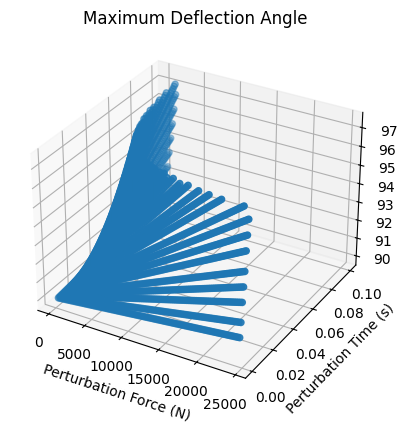

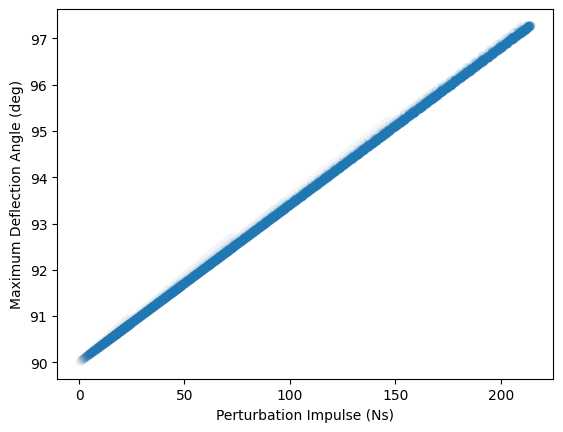

'dampHuman.csv'

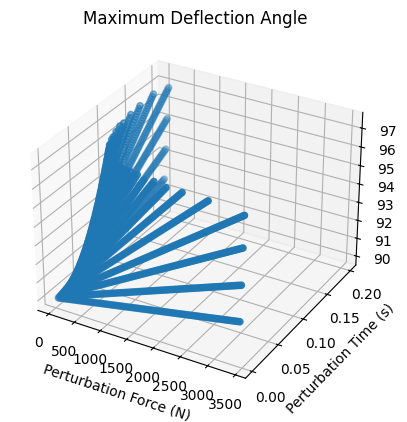

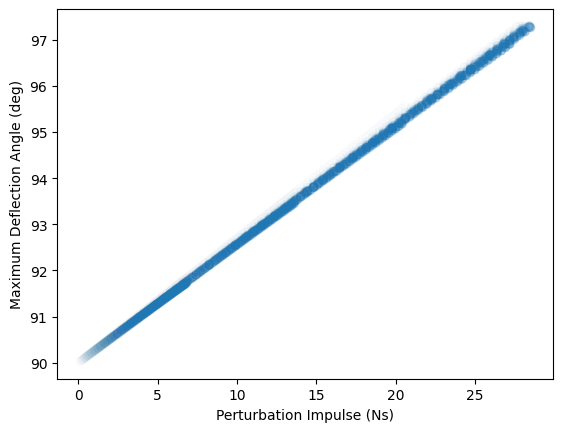

'catDamp.csv'

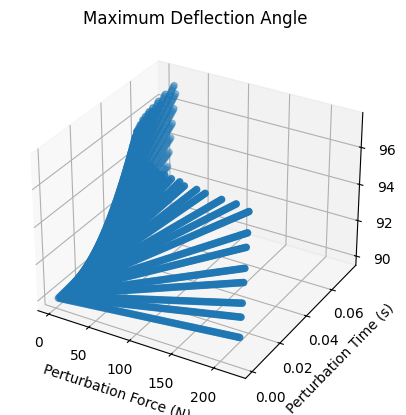

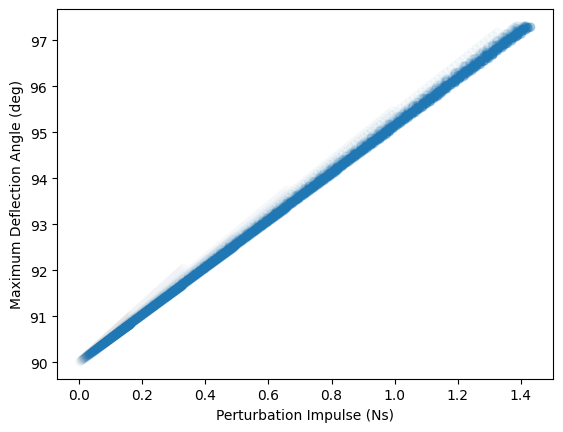

'ratDamp.csv'

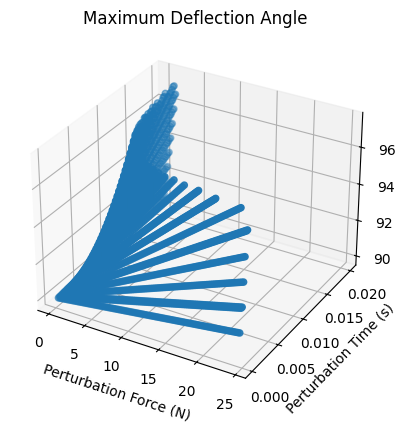

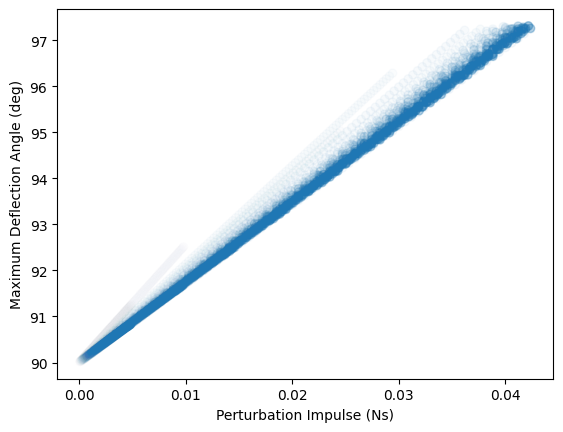

'mouseDamp.csv'

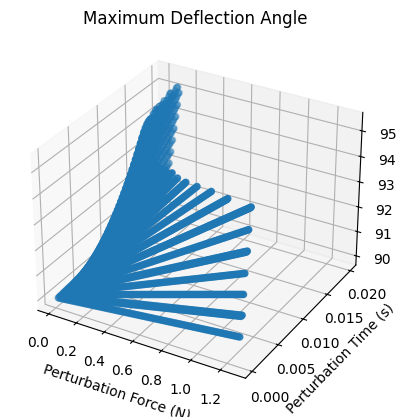

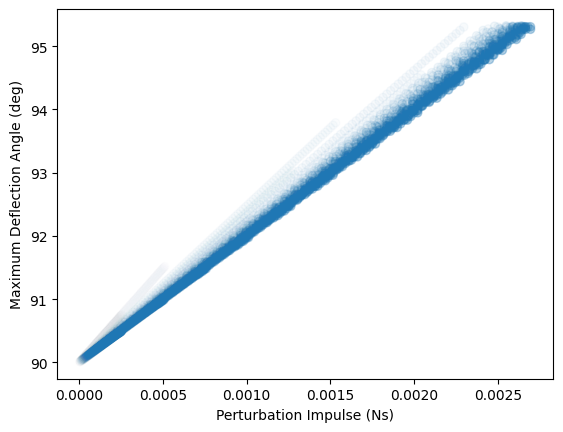

'cockroachWideDampFix.csv'

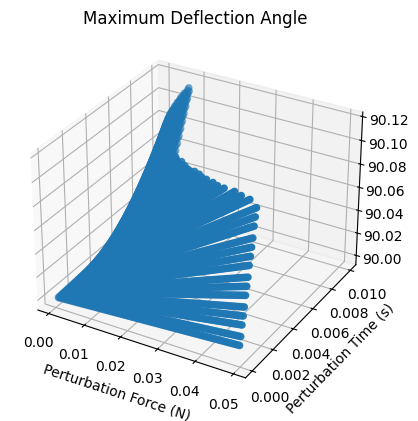

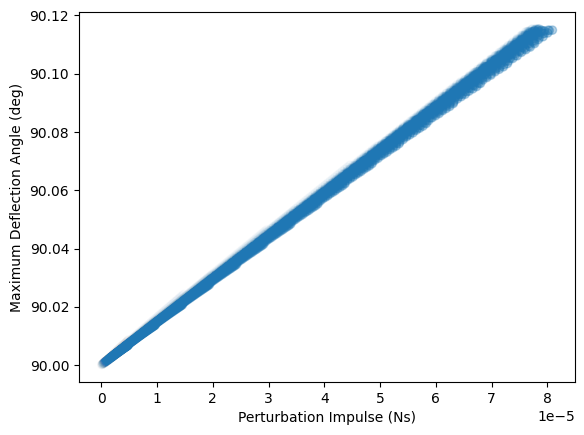

'flyWideDampFix.csv'

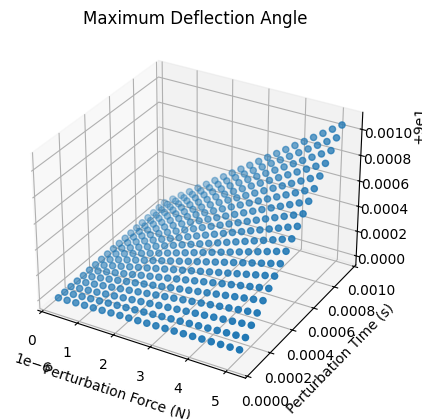

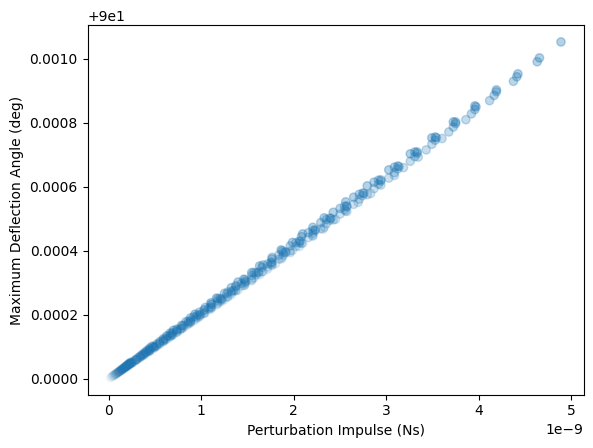

[np.float64(29.458480304146633), np.float64(3.8807853882600822), np.float64(0.19381213793303712), np.float64(0.005634877709424855), np.float64(0.0004910467219941773), np.float64(0.0006806956515770288), np.float64(4.704905229610004e-06)]
[1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]


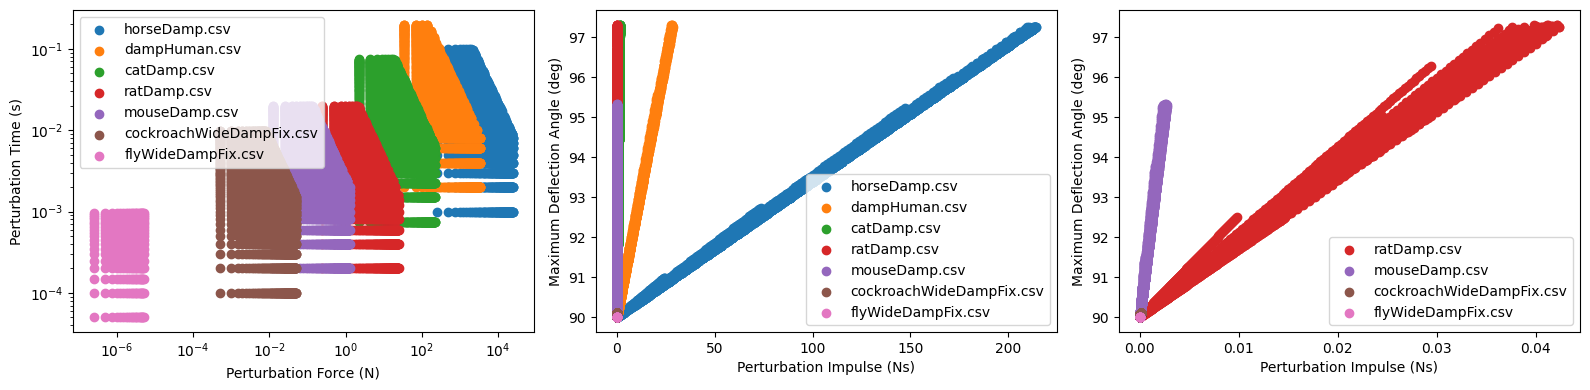

[np.float64(29.458480304146633), np.float64(3.8807853882600822), np.float64(0.19381213793303712), np.float64(0.005634877709424855), np.float64(0.0004910467219941773), np.float64(0.0006806956515770288), np.float64(4.704905229610004e-06)]
[1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]
[1.90790303 0.58974062]


'Testing: 2.8196837548095335'

'Found: 1.907903034487406'

'Slope: [ 1.46921034  0.58891963 -0.71261903 -2.2491155  -3.30887718 -3.16704702\n -5.32744912]'

[   4.70490523 -423.44143977]


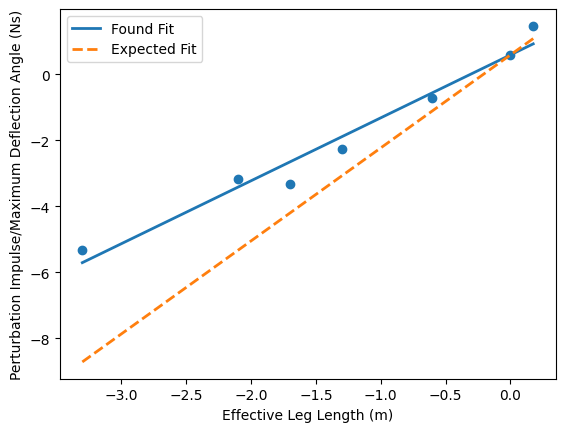

[np.float64(29.458480304146633), np.float64(3.8807853882600822), np.float64(0.19381213793303712), np.float64(0.005634877709424855), np.float64(0.0004910467219941773), np.float64(0.0006806956515770288), np.float64(4.704905229610004e-06)]
[1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]
False
False
False
False
False
True
False


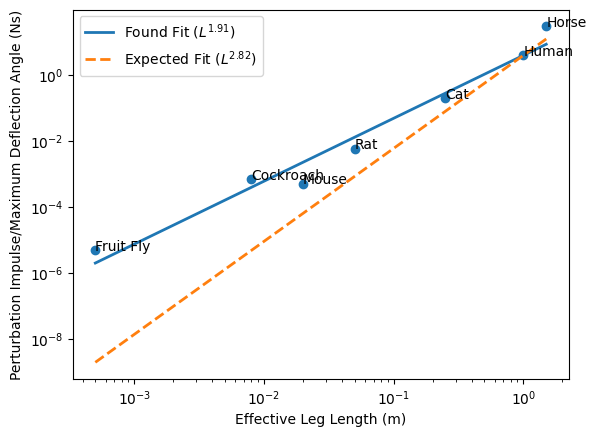

In [ ]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib import cm
from scipy.optimize import curve_fit
from adjustText import adjust_text

# %matplotlib notebook

# Have not run w/ csv file reading yet
# csv_file = "human.csv"
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7]
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]
Length, Mass = [], []
number = [0, 1, 2, 3, 4, 5, 6]
# number = [1, 6]
number = [0, 1, 2, 3, 4, 5, 6]
n1 = 5

for i in number:
    Length.append(Li[i])
    Mass.append(Mi[i])
# Length = [Li[0], Li[1], Li[2]]
# Length = [Li[3], Li[5]]
# Length = [Li[1], Li[1]]

slope = []


def line(x, m, b):
    return m * x + b


def exponent(x, m, b, c):
    return m * np.pow(x, b) + c


def logfit(x, m, b):
    return b * np.log10(x) + m


def testfit(x, a, b):
    return a * x**b


def reverseLog(x, m, b):
    return 10 ** (m * x + b)


# Scale mass
fit = np.polyfit(np.log10(Length), np.log10(Mass), 1)
display("Mass scaling: " + str(fit[0]))
test = 1.5 + fit[0] / 2
if n1 == 1:
    names = [
        "horse1.csv",
        "human1.csv",
        "cat1.csv",
        "rat1.csv",
        "mouse1.csv",
        "cockroach1.csv",
        "fly1.csv",
    ]
elif n1 == 2:
    names = [
        "horseUndamp.csv",
        "human1.csv",
        "catUndamp.csv",
        "ratUndamp.csv",
        "mouseUndamp.csv",
        "cockroachUndamp.csv",
        "flyUndamp.csv",
    ]
elif n1 == 3:
    names = [
        "horseDamp.csv",
        "dampHuman.csv",
        "catDamp.csv",
        "ratDamp.csv",
        "mouseDamp.csv",
        "cockroachDamp.csv",
        "flyDamp.csv",
    ]
elif n1 == 4:
    names = [
        "horseUndamp.csv",
        "human1.csv",
        "catUndamp.csv",
        "ratUndamp.csv",
        "mouseUndamp.csv",
        "cockroachWide.csv",
        "flyWideFix.csv",
    ]
elif n1 == 5:
    names = [
        "horseDamp.csv",
        "dampHuman.csv",
        "catDamp.csv",
        "ratDamp.csv",
        "mouseDamp.csv",
        "cockroachWideDampFix.csv",
        "flyWideDampFix.csv",
    ]


# names = [
#     "horseUndamp.csv",
#     "human1.csv",
#     "catUndamp.csv",
#     "ratUndamp.csv",
#     "mouseUndamp.csv",
#     "cockroachWide.csv",
#     "flyWideFix.csv",
# ]
# names = [
#     "horseUndamp.csv",
#     "human1.csv",
#     "catUndamp.csv",
#     "ratUndamp.csv",
#     "mouseUndamp.csv",
#     "cockroachWide.csv",
#     "flyWideFix.csv",
# ]

# names = [
#     "1dampHorse.csv",
#     "1dampHuman.csv",
#     "1dampCat.csv",
#     "1dampRat.csv",
#     "1dampMouse.csv",
#     "1dampCockroach.csv",
#     "1dampFly.csv",
# ]
# names = ["horse.csv", "human.csv", "cat.csv", "rat.csv"]
# names = ["human.csv", "cat.csv", "rat.csv"]
# names = ["human.csv", "testc.csv"]
# names = ["rat.csv", "cockroach.csv"]
# names = ["h2.csv", "h1.csv"]
X, Y, Z, t, alpha, angle, force, s, imp, scaleimp = (
    [],
    [],
    [],
    [],
    [],
    [],
    [],
    [],
    [],
    [],
)
tfit, ffit = [], []
for j in range(len(names)):
    alpha.append([])
    X.append([])
    Y.append([])
    Z.append([])
    t.append([])
    angle.append([])
    force.append([])
    s.append([])
    imp.append([])
    scaleimp.append([])
    # alpha.append([])
    fileName = names[j]
    data = []
    with open(fileName, "r") as csv_file:
        csv_reader = csv.reader(csv_file)
        display(csv_reader)
        for rows in csv_reader:
            data.append(rows)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    for i in range(len(data) - 1):
        X[j].append(float(data[i + 1][0]))  ##4
        Y[j].append(float(data[i + 1][1]))  # 3
        Z[j].append(float(data[i + 1][3]))  # 2 #4
        t[j].append(float(data[i + 1][1]))  # DO NOT CHANGE
        imp[j].append(float(data[i + 1][4]))
        scaleimp[j].append(float(data[i + 1][4]) * 1e6)
        angle[j].append(float(data[i + 1][3]))
        force[j].append(float(data[i + 1][0]))
        s[j].append(angle[j][i] / force[j][i])
    for i in range(len(data) - 1):
        alpha[j].append(float(data[i + 1][1]) / max(t[j]) / 3)
    # plot = plt.tricontourf(X, Y, Z, levels=999)
    # x = np.reshape(X, (27, 40))
    # y = np.reshape(Y, (27, 40)
    # z = np.reshape(Z, (27, 40))
    # print(X)
    display(fileName)
    ax.scatter(X[j], Y[j], Z[j])
    # ax.set_xlim(0, 150000)  # Set x-limits from 0 to 5
    # ax.set_ylim(0, 1)  # Set y-limits from 2 to 8
    # ax.view_init(elev=30, azim=-225)
    # ax.scatter(X, Y, Z)
    # cbar = fig.colorbar(cax, ticks=[-1, 0, 1])
    # cbar = plt.colorbar(plot)
    plt.title("Maximum Deflection Angle")
    plt.xlabel("Perturbation Force (N)")
    plt.ylabel("Perturbation Time (s)")
    plt.show()

    fig = plt.figure()
    ax = fig.add_subplot()
    # ax.scatter(np.log10(X), np.log10(Y))
    # X[j] = [0, 1, 2, 3, 4, 5]
    # Y[j] = [3, 4, 5, 6, 7, 8]
    x = X[j]
    y = Y[j]
    x = imp[j]
    y = angle[j]
    b, cov = curve_fit(line, scaleimp[j], y)
    # slope.append(b[0] * 1e-6)

    b, cov = curve_fit(line, y, scaleimp[j])
    slope.append(b[0] * 1e-6)
    # print(b[0])
    # print(b[1])
    ax.scatter(imp[j], angle[j], alpha=alpha[j])
    plt.xlabel("Perturbation Impulse (Ns)")
    plt.ylabel("Maximum Deflection Angle (deg)")
    # ax.scatter(X[j], Z[j])
    plt.show()

    # # Theta/F vs t
    # Slope, times = [], []
    # min_time = min(t[j])
    # time = min_time
    # max_time = max(t[j])
    # ndig = round(math.log10(1 / min_time)) + 1
    # while time <= max_time:
    #     phi, Force = [], []
    #     for i in range(len(t[j])):
    #         if round(t[j][i], ndig) == round(time, ndig):
    #             phi.append(angle[j][i])
    #             Force.append(force[j][i])
    #     if len(phi) < 2:
    #         break
    #     b, cov = curve_fit(line, Force, phi)
    #     Slope.append(b[0])
    #     times.append(time)
    #     time += min_time
    # fig = plt.figure()
    # plt.plot(times, Slope)
    # plt.show()
    # b, cov = curve_fit(line, times, Slope)
    # tfit.append(b[0])

    # # Theta/t vs F
    # Slope, forces = [], []
    # min_force = min(force[j])
    # Force = min_force
    # max_force = max(force[j])
    # ndig = round(math.log10(1 / min_force)) + 1
    # while Force <= max_force:
    #     phi, time = [], []
    #     for i in range(len(t[j])):
    #         if round(force[j][i], ndig) == round(Force, ndig):
    #             phi.append(angle[j][i])
    #             time.append(t[j][i])
    #     if len(phi) < 2:
    #         break
    #     b, cov = curve_fit(line, time, phi)
    #     Slope.append(b[0])
    #     forces.append(Force)
    #     Force += min_force
    # fig = plt.figure()
    # plt.plot(forces, Slope)
    # print(len(Slope))
    # print(len(forces))
    # plt.show()
    # b, cov = curve_fit(line, forces, Slope)
    # ffit.append(b[0])


# Plot both layered figures
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(
    1,
    3,
    1,
)
for j in range(len(names)):
    ax.scatter(X[j], Y[j], label=(names[j][:]))  # -4
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlabel("Perturbation Force (N)")
plt.ylabel("Perturbation Time (s)")
# ax.set_xlim(0, .4)
plt.legend(loc="upper left")

# plt.show()

# fig = plt.figure()

ax = fig.add_subplot(1, 3, 2)
# b, cov = curve_fit(logfit, np.log10(Length), np.log10(slope))
# b, cov = curve_fit(exponent, Length, slope)
print(slope)
print(Length)
fit = np.polyfit(np.log10(Length), np.log10(slope), 1)
# print(b[0] * Li[j] ** b[1])
for j in range(len(names)):
    ax.scatter(imp[j], angle[j], label=(names[j][:]))  # -4
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlim(0, .4)
plt.xlabel("Perturbation Impulse (Ns)")
plt.ylabel("Maximum Deflection Angle (deg)")
plt.legend()

ax = fig.add_subplot(1, 3, 3)
n = 3
for j in range(len(names) - n):
    ax.scatter(
        imp[j + n], angle[j + n], label=(names[j + n][:]), color=color[j + n]
    )  # -4
plt.xlabel("Perturbation Impulse (Ns)")
plt.ylabel("Maximum Deflection Angle (deg)")
plt.legend()

plt.tight_layout()
plt.show()


fig = plt.figure()
ax = fig.add_subplot()
# print(Length)
# print(slope)
x_line = np.linspace(min(np.log10(Length)), max(np.log10(Length)))
print(slope)
print(Length)
ax.scatter(np.log10(Length), np.log10(slope))
print(fit)
display("Testing: " + str(test))
display("Found: " + str(fit[0]))
display("Slope: " + str(np.log10(slope)))
ax.plot(x_line, line(x_line, fit[0], fit[1]), label="Found Fit", linewidth=2)
ax.plot(x_line, line(x_line, test, fit[1]), label="Expected Fit", ls="--", linewidth=2)
plt.xlabel("Effective Leg Length (m)")
plt.ylabel("Perturbation Impulse/Maximum Deflection Angle (Ns)")
# ax.plot(x_line, line(x_line, b[0], b[1], b[2]))
print(b)
# ax.set_xscale("log")
# ax.set_yscale("log")
plt.legend()
plt.show()

# found_fit = r"Found Fit ($L^{2.80}$)"
found_fit = r"Found Fit ($L^{" + str(round(fit[0], 3)) + r"}$)"
fig = plt.figure()
ax = fig.add_subplot()
# print(Length)
# print(slope)
x_line = np.linspace(min(Length), max(Length))
print(slope)
print(Length)
ax.scatter(Length, slope)
ax.plot(
    x_line,
    reverseLog(np.log10(x_line), fit[0], fit[1]),
    label=r"Found Fit ($L^{" + str(round(fit[0], 2)) + r"}$)",
    linewidth=2,
)
ax.plot(
    x_line,
    reverseLog(np.log10(x_line), test * 1, fit[1]),
    label=r"Expected Fit ($L^{2.82}$)",
    ls="--",
    linewidth=2,
)
plt.xlabel("Effective Leg Length (m)")
plt.ylabel("Perturbation Impulse/Maximum Deflection Angle (Ns)")
# print(fit)
# ax.plot(x_line, line(x_line, fit[0], fit[1]))
# print(b)
ax.set_xscale("log")
ax.set_yscale("log")
for i, txt in enumerate(name):
    ax.annotate(txt, (Length[i], slope[i]))
    print((n1 == 5 and txt == "Cockroach"))
    if n1 == 5 and txt == "Cockroach":
        arrowprops = dict(facecolor="red", shrink=0.05, xytext=(3, 4))
    else:
        arrowprops = dict(facecolor="black", shrink=0.05)
    # adjust_text(txt, arrowprops=dict(arrowstyle="->", color='red', lw=0.5))
plt.legend()
plt.show()

# fig = plt.figure()
# print("time")
# ax = fig.add_subplot()
# ax.scatter(Length, tfit)
# b, cov = curve_fit(exponent, Length, tfit)
# ax.plot(x_line, exponent(x_line, b[0], b[1], b[2]))
# ax.set_xscale("log")
# ax.set_yscale("log")

# print(b)
# plt.show()

# fig = plt.figure()
# print("force")
# ax = fig.add_subplot()
# ax.scatter(Length, ffit)
# b, cov = curve_fit(exponent, Length, ffit)
# ax.plot(x_line, exponent(x_line, b[0], b[1], b[2]))
# ax.set_xscale("log")
# ax.set_yscale("log")

# print(b)
# plt.show()
# print(tfit)
# print(ffit)

2.6393675096190674


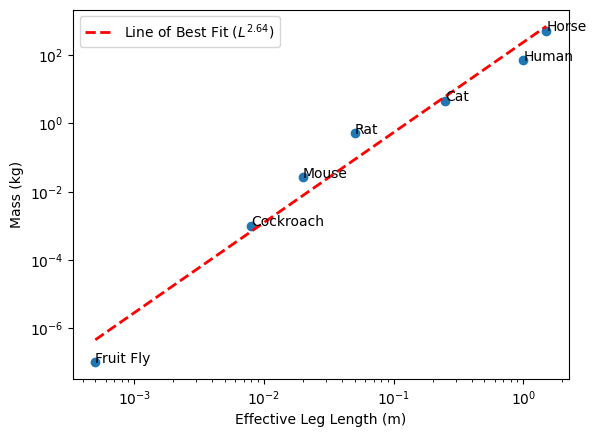

[70.02352087  4.8481898 ]
171.47485980414382
70
4.139683754809534


In [44]:
# Code set aside for simply scaling certain things
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7]
num = [2, 1, 2, 2, 2, 3, 3]
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]
Length, Mass = [], []
number = [0, 1, 2, 3, 4, 5, 6]
# number = [1, 6]

for i in number:
    Length.append(Li[i])
    Mass.append(Mi[i])


def testfit(x, a, b):
    return a * x**b


# Scale mass
n = 1
fig = plt.figure()
ax = fig.add_subplot()
x_line = np.linspace(min(Length), max(Length))
# ax.scatter(np.log10(Length), np.log10(Mass))
ax.scatter(Length, Mass)
fit = np.polyfit(np.log10(Length), np.log10(Mass), 1)
print(fit[0])
# ax.plot(x_line, line(x_line, fit[0], fit[1]), label="Found Fit", linewidth=2)
ax.plot(
    x_line,
    reverseLog(np.log10(x_line), fit[0], fit[1]),
    color="red",
    label=r"Line of Best Fit ($L^{2.64}$)",
    ls="--",
    linewidth=2,
)
plt.xlabel("Effective Leg Length (m)")
plt.ylabel("Mass (kg)")
ax.set_xscale("log")
ax.set_yscale("log")
for i, txt in enumerate(name):
    ax.annotate(txt, (Li[i], Mass[i]))
    arrowprops = dict(facecolor="black", shrink=0.05)
plt.legend()
plt.show()

b, cov = curve_fit(testfit, Length, Mass)
print(b)
print(Mass[0] * (Length[n] / Length[0]) ** fit[0])
print(Mass[n])
# print(2.82 + fit[0])
print(2.64 * 0.5 + 1 + (1 + fit[0]) * 0.5)

In [ ]:
# Old code
import mujoco
import mediapy as media
import time
import itertools
import numpy as np
import math
import matplotlib.pyplot as plt

# Set up initial values
num = [6]
name = ["Horse", "Human", "Cat", "Rat", "Mouse", "Cockroach", "Fruit Fly"]
num_legs = [2, 1, 2, 2, 2, 3, 3]
Li = [1.5, 1, 0.25, 0.05, 0.02, 0.008, 0.0005]
Mi = [500, 70, 4.5, 0.500, 0.026, 0.001, 1e-7]

# Edit these to fit animal
knee_starti = [0, 90 * 0, 0, 0, 0, 130 * 0, 130 * 0]
stance_width = [1, 1, 1, 1, 1, 5 / 5, 5 / 5]
front = [0, 0, 0, 0, 0, 0]

out = 1
ortho = False
timestep = 0.0001
seconds = 5
pert = 1

knee_out = [5 * out, 5 * out, 4 * out, 3.5 * out, 3 * out, 3 * out, 1.5 * out]
mag = [1, 1, 1, 1, 1, 100, 1000]
T_vec = [0.880, 0.500, 0.250, 0.200, 0.100, 0.044, 0.050]
w_frequency, n_frequency, Li_mod = [], [], []
counter = 0
while counter <= len(T_vec) - 1:
    w_frequency.append(2 * math.pi / T_vec[counter])
    counter += 1
if ortho == True:
    xy = "1 1 0 0 0 1"
    # xy = "0 1 0 0 0 1"
    offset = 25
else:
    xy = "1 0 0 0 0 1"
    offset = 1


# Findpeaks code
def getFrequency(t, a):
    first_peak = 0
    second_peak = 0
    y = 100
    count = int(len(t) / 3)
    pos = -1
    while count < len(t) * 2 / 3:
        if a[count] == max(a[count - y : count + y]):
            first_peak = count
            count += y
            break
        count += 1
    if a[first_peak] > ank_start:
        pos = 1
    while count < len(t):
        if (
            a[count] == max(a[count - y : count + y])
            and a[count] * pos > ank_start * pos
        ):
            second_peak = count
            break
        count += 1
    print(
        "Damping: "
        + str(
            abs(
                math.log(a[first_peak] / a[second_peak])
                / math.sqrt(
                    (2 * math.pi) ** 2 + math.log(a[first_peak] / a[second_peak]) ** 2
                )
            )
        )
    )
    return abs(1 / (t[first_peak] - t[second_peak]) * 2 * math.pi)


# Iterate through simulation
for i in num:
    print(name[i] + ":")
    L = Li[i] * mag[i]
    M = Mi[i] * mag[i]
    L_COM = 0.293 / 0.530 * L
    W = L * 0.134 / 0.530
    H = L * 0.108 / 0.530
    S = W * stance_width[i]

    hip_stiff = 12000 * 0.001 * math.pow(L, 3) * 8 / 0.29 / num_legs[i]
    # hip_stiff = hip_stiff*num_legs[i]
    knee_stiff = hip_stiff * math.pow(10, knee_out[i]) / 7

    I_leg = 0.030 * M * math.pow(L / 0.530, 2)
    I_torso = 0.020 * M * math.pow(L / 0.530, 2)

    constraint_M = M * 10000000
    constraint_I = 0.0000001 * I_leg

    hip_ang = 90
    knee_start = knee_starti[i]

    x_dist = (S - W) / 2
    if S == W:
        y_dist = 0
    else:
        y_dist = x_dist * math.tan(hip_ang / 180 * math.pi)
    dist = math.sqrt(math.pow(x_dist, 2) + math.pow(y_dist, 2))
    ank_start = math.acos(dist / L) * 180 / math.pi + knee_start / 2
    hip_start = ank_start - knee_start
    L = L / math.sqrt((1 - math.cos((180 - knee_start) / 180 * math.pi)) / 2)
    # hip_ang = -hip_ang
    z_dist = L / 2 * math.sin(ank_start / 180 * math.pi) + L / 2 * math.sin(
        (hip_start) / 180 * math.pi
    )
    lower_x_dist = (
        L / 2 * math.cos(ank_start / 180 * math.pi) * math.cos(hip_ang / 180 * math.pi)
    )
    lower_y_dist = (
        L / 2 * math.cos(ank_start / 180 * math.pi) * math.sin(hip_ang / 180 * math.pi)
    )
    lower_z_dist = L / 2 * math.sin(ank_start / 180 * math.pi)
    L_COM = 0.293 / 0.530 * L
    Damp = 0

    # print("x_dist: " + str(x_dist))
    # print(
    #     "x-guess: "
    #     + str(
    #         (
    #             L / 2 * math.cos(ank_start / 180 * math.pi)
    #             + L / 2 * math.cos(hip_start / 180 * math.pi)
    #         )
    #         * math.cos(hip_ang / 180 * math.pi)
    #     )
    # )
    # print("y_dist: " + str(y_dist))
    # print(
    #     "y_guess: "
    #     + str(
    #         (
    #             L / 2 * math.cos(ank_start / 180 * math.pi)
    #             + L / 2 * math.cos(hip_start / 180 * math.pi)
    #         )
    #         * math.sin(hip_ang / 180 * math.pi)
    #     )
    # )
    # print("z_dist: " + str(z_dist))
    # print(
    #     "z_guess: "
    #     + str(
    #         (
    #             L / 2 * math.sin(ank_start / 180 * math.pi)
    #             + L / 2 * math.sin(hip_start / 180 * math.pi)
    #         )
    #     )
    # )
    # print("S, 2x+W: " + str(S) + ", " + str(2 * x_dist + W))
    if i == 6:
        timestep /= 10
    # num_legs[i]=1
    rl1 = ""
    rl2 = ""
    ll1 = ""
    ll2 = ""
    weld1 = ""
    weld2 = ""
    if num_legs[i] > 1:
        rl1 = f"""
        <body name ="right_leg1">
          <inertial pos="{S-L_COM/L*x_dist} {L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip1" type="hinge" axis="0 1 0" pos="{S-x_dist} {L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh1" type="box" pos="{S-(x_dist+lower_x_dist)/2} {L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16}"/>
          <body name="lower_right1">
            <joint name="right_knee1" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{Damp}"/>
            <geom name="right_shank1" type="box" pos="{S-lower_x_dist/2} {L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16}" friction="0"/>
            <body name="right1">
              <inertial pos = "{S} {L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle1" type="hinge" pos="{S} {L/3} 0" stiffness="0" damping="0"/>
              <body name = "right_foot1">
                <geom name="right_f1" pos="{S} {L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
        ll1 = f"""
        <body name ="left_leg1">
          <inertial pos="{L_COM/L*x_dist} {L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip1" type="hinge" axis="0 1 0" pos="{x_dist} {L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh1" type="box" pos="{(x_dist+lower_x_dist)/2} {L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16}"/>
          <body name="lower_left1">
            <joint name="left_knee1" type="hinge" axis="0 1 0" pos="{lower_x_dist} {L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{Damp}"/>
            <geom name="left_shank1" type="box" pos="{lower_x_dist/2} {L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16}" friction="0"/>
            <body name="left1">
              <inertial pos = "0 {L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle1" type="hinge" pos="0 {L/3} 0" stiffness="0" damping="0"/>
              <body name = "left_foot1">
                <geom name="left_f1" pos="0 {L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        """
        weld1 = f"""
      <weld body1 ="right_foot1" body2 ="world" anchor="{S} {L/3} 0"/>
      <weld body1 ="left_foot1" body2 ="world" anchor="0 {L/3} 0"/>
    """
    if num_legs[i] > 2:
        rl2 = f"""
        <body name ="right_leg2">
          <inertial pos="{S-L_COM/L*x_dist} {2*L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip2" type="hinge" axis="0 1 0" pos="{S-x_dist} {2*L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh2" type="box" pos="{S-(x_dist+lower_x_dist)/2} {2*L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16}"/>
          <body name="lower_right2">
            <joint name="right_knee2" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {2*L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{Damp}"/>
            <geom name="right_shank2" type="box" pos="{S-lower_x_dist/2} {2*L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16}" friction="0"/>
            <body name="right2">
              <inertial pos = "{S} {2*L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle2" type="hinge" pos="{S} {2*L/3} 0" stiffness="0" damping="0"/>
              <body name = "right_foot2">
                <geom name="right_f2" pos="{S} {2*L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
    """
        ll2 = f"""
        <body name ="left_leg2">
          <inertial pos="{L_COM/L*x_dist} {2*L/3+(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip2" type="hinge" axis="0 1 0" pos="{x_dist} {2*L/3+y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh2" type="box" pos="{(x_dist+lower_x_dist)/2} {2*L/3+(lower_y_dist+y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16}"/>
          <body name="lower_left2">
            <joint name="left_knee2" type="hinge" axis="0 1 0" pos="{lower_x_dist} {2*L/3+lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{Damp}"/>
            <geom name="left_shank2" type="box" pos="{lower_x_dist/2} {2*L/3+lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16}" friction="0"/>
            <body name="left2">
              <inertial pos = "0 {2*L/3} 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle2" type="hinge" pos="0 {2*L/3} 0" stiffness="0" damping="0"/>
              <body name = "left_foot2">
                <geom name="left_f2" pos="0 {2*L/3} 0" size="{0.0005*L}" rgba="0 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        """
        weld2 = f"""
      <weld body1 ="right_foot2" body2 ="world" anchor="{S} {2*L/3} 0"/>
      <weld body1 ="left_foot2" body2 ="world" anchor="0 {2*L/3} 0"/>
    """

    # Create xml file
    xml = f"""
  <?xml version="1.0" ?>
  <mujoco>
    <option integrator="RK4" gravity="0 0 {-9.81*0}" timestep="{timestep}" viscosity = "0" density = "0" o_friction="0 0 0 0 0"/>
    <compiler eulerseq = "zyx"/>
    <worldbody>
      <light name="top" pos="0 0 {5*L}"/>
      <camera name="fixed" pos="{offset*S/2} {-3*L} {z_dist/2}" xyaxes="{xy}"/>
      <body name="model">
        <body name ="left_leg">
          <inertial pos="{L_COM/L*x_dist} {(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="left_hip" type="hinge" axis="0 1 0" pos="{x_dist} {y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="left_thigh" type="box" pos="{(lower_x_dist+x_dist)/2} {(lower_y_dist+y_dist)/2} {(lower_z_dist+z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-hip_start} 0" rgba="0 1 1 1" mass = "{M/16}"/>
          <body name="lower_left">
            <joint name="left_knee" type="hinge" axis="0 1 0" pos="{lower_x_dist} {lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{Damp}"/>
            <geom name="left_shank" type="box" pos="{lower_x_dist/2} {lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{hip_ang} {90-ank_start} 0" rgba="0 0 1 1" mass = "{M/16}" friction="0"/>
            <body name="left">
              <inertial pos = "0 0 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="left_ankle" type="ball" pos="0 0 0" stiffness="0" damping="0"/>
              <body name = "left_foot">
                <geom name="left_f" pos="0 0 0" size="{0.0005*L}" rgba="1 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        "{ll1}"
        "{ll2}"
        <freejoint/>
        <body name="torso">
          <geom name="pelvis" type="box" pos="{W/2+x_dist} {L/6*(num_legs[i]-1)+y_dist} {z_dist+H}" size="{W/2} {0.005*L*num_legs[i]+L/6*(num_legs[i]-1)} {H}" rgba="1 1 0 1" mass = "{3/4*M}"/>
          <inertial pos="{W/2+x_dist} {L/6*(num_legs[i]-1)+y_dist} {z_dist+H}" mass = "{3/4*M}" diaginertia="{I_torso} {I_torso} {I_torso}"/>
        </body>
        <body name ="right_leg">
          <inertial pos="{S-L_COM/L*x_dist} {(L_COM/L)*y_dist} {L_COM/L*z_dist}" mass="{M/8}" diaginertia="{I_leg} {I_leg} {I_leg}"/>
          <joint name="right_hip" type="hinge" axis="0 1 0" pos="{S-x_dist} {y_dist} {z_dist}" stiffness = "{hip_stiff}" damping = "{Damp}"/>
          <geom name="right_thigh" type="box" pos="{S-(x_dist+lower_x_dist)/2} {(y_dist+lower_y_dist)/2} {(z_dist+lower_z_dist)/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+hip_start} 0" rgba="0 1 1 1" mass = "{M/16}"/>
          <body name="lower_right">
            <joint name="right_knee" type="hinge" axis="0 1 0" pos="{S-lower_x_dist} {lower_y_dist} {lower_z_dist}" stiffness="{knee_stiff}" damping="{Damp}"/>
            <geom name="right_shank" type="box" pos="{S-lower_x_dist/2} {lower_y_dist/2} {lower_z_dist/2}" size="{0.005*L} {0.005*L} {L/4}" euler = "{-hip_ang} {90+ank_start} 0" rgba="0 0 1 1" mass = "{M/16}" friction="0"/>
            <body name="right">
              <inertial pos = "{S} 0 0" mass = "{constraint_M}" diaginertia = "{constraint_I} {constraint_I} {constraint_I}"/>
              <joint name="right_ankle" type="ball" pos="{S} 0 0" stiffness="0" damping="0"/>
              <body name = "right_foot">
                <geom name="right_f" pos="{S} 0 0" size="{0.0005*L}" rgba="1 1 0 0"/>
              </body>
            </body>
          </body>
        </body>
        "{rl1}"
        "{rl2}"
      </body>
    </worldbody>
    <equality>
      <weld body1 ="right_foot" body2 ="world" anchor="{S} 0 0"/>
      <weld body1 ="left_foot" body2 ="world" anchor="0 0 0"/>
      "{weld1}"
      "{weld2}"
    </equality>
  </mujoco>
  """

    # Simulate
    model = mujoco.MjModel.from_xml_string(xml)
    data = mujoco.MjData(model)
    n_frames = 60 * seconds
    height = 480
    width = 640
    fps = 60.0
    frames, angle, times = [], [], []

    renderer = mujoco.Renderer(model, height, width)

    mujoco.mj_resetData(model, data)
    N = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso")
    # perturb initial velocities
    data.qvel[4] = pert  # root joint velocity

    # Simulate and display video.
    for j in range(n_frames):
        while data.time < j / fps:
            mujoco.mj_step(model, data)
            times.append(data.time)
            # angle.append(ank_start + math.asin(data.geom_xmat[1][2]) * 180 / math.pi)
            angle.append(getAngle(data.xpos[N], data.geom_xmat[1][2]))
        renderer.update_scene(data, "fixed")
        frame = renderer.render()
        frames.append(frame)

    # Plot simulation
    plt.plot(
        times[int(len(times) / 2) : len(times)], angle[int(len(angle) / 2) : len(angle)]
    )
    plt.show()

    f = getFrequency(times, angle)
    print("Frequency: " + str(f))
    n_frequency.append(f)
    Li_mod.append(Li[i])
    media.show_video(frames, fps=fps)

# Plot frequencies
fig, ax = plt.subplots(figsize=(9, 6))
plt.xlabel("Effective Leg Length (m)")
plt.ylabel("Frequency (rad/s)")
plt.scatter(Li, w_frequency, color="red", label="Walking Frequency")
plt.loglog(
    Li,
    10
    ** (
        np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=1))(np.log10(Li))
    ),
    linestyle="dashed",
    color="red",
)
a, b = np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=1))
print(-a)
print(b)
plt.loglog(
    Li,
    10
    ** (
        np.poly1d(np.polyfit(np.log10(Li), np.log10(w_frequency), deg=6))(np.log10(Li))
    ),
    color="red",
)
plt.scatter(Li_mod, n_frequency, color="blue", label="Natural Frequency")
if len(n_frequency) > 1:
    plt.loglog(
        Li_mod,
        10
        ** (
            np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(n_frequency), deg=1))(
                np.log10(Li_mod)
            )
        ),
        linestyle="dashed",
        color="blue",
    )
    plt.loglog(
        Li_mod,
        10
        ** (
            np.poly1d(
                np.polyfit(
                    np.log10(Li_mod), np.log10(n_frequency), deg=len(n_frequency) - 1
                )
            )(np.log10(Li_mod))
        ),
        color="blue",
    )
    a, b = np.poly1d(np.polyfit(np.log10(Li_mod), np.log10(n_frequency), deg=1))
    print(-a)
    print(b)
for i, txt in enumerate(name):
    ax.annotate(txt, (Li[i], w_frequency[i]))
plt.legend()